In [1]:
# a & e data are read in from .csv files

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ReadParticle import read_particle 
from datetime import datetime, timedelta

# Function to convert meters to kilometers
def m_to_km(x, _):
    return f'{x / 1000:.1f}'

# Read particle and collision data
Np_seq, time, N_colDidy, N_colDimor, N_escape, r_dust, particle, data_c, data_p = read_particle('particles.txt', 'collide.txt')

No. 1913 of output frame has been analyzed (100.0%)



In [45]:
# Constants
G = 6.6743e-11
mass_system = 5.5e11
sep_system = 1170.0
mu_system = 6.6743e-11 * 5.5e11
vol_didy = 0.2295409644951028e9
vol_dimor = 0.001830603200702610e9
mass_didy = mass_system * vol_didy / (vol_didy + vol_dimor)
mass_dimor = mass_system * vol_dimor / (vol_didy + vol_dimor)

r_dimor_com = vol_didy*sep_system/(vol_didy+vol_dimor)
v_dimor_com = -np.sqrt(G*mass_didy/sep_system**2*r_dimor_com)
v_dimor_com

-0.17572821136485348

# Plotting ejecta type ...


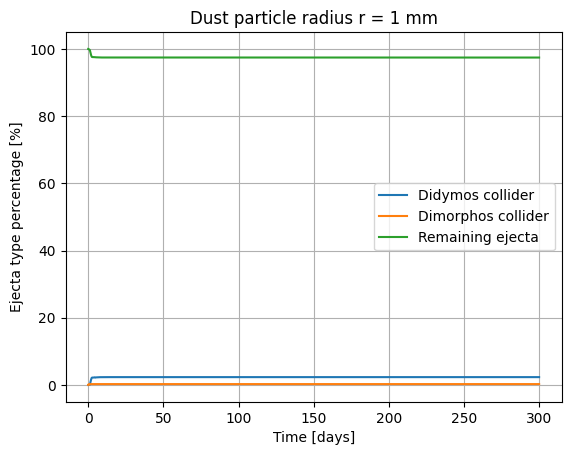

# Ejecta type completed!



In [2]:
# Plotting ejecta type
if (1):
    print("# Plotting ejecta type ...",flush=True)
    plt.figure()
    plt.plot(np.append(np.insert(N_colDidy[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDidy[:,1],0,0),N_colDidy[-1,1]) / Np_seq[0] * 100,
             label='Didymos collider', linewidth=1.5)
    plt.plot(np.append(np.insert(N_colDimor[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDimor[:,1],0,0),N_colDimor[-1,1]) / Np_seq[0] * 100,
             label='Dimorphos collider', linewidth=1.5)
    # plt.plot(np.append(np.insert(N_escape[:,0],0,0),time[-1]) / 24 / 3600,
    #          np.append(np.insert(N_escape[:,1],0,0),N_escape[-1,1]) / Np_seq[0] * 100,
    #          label='Escaped ejecta', linewidth=1.5)
    #plt.plot(np.insert(time_sort, 0, 0) / 24 / 3600, np.insert(N_sort, 0, 0) / Np_seq[0] * 100, label='Escaped ejecta', linewidth=1.5)
    plt.plot(time / 24 / 3600,
             Np_seq / Np_seq[0] * 100,
             label='Remaining ejecta', linewidth=1.5)
    plt.xlabel('Time [days]')
    plt.ylabel('Ejecta type percentage [%]')
    plt.title('Dust particle radius r = 1 mm')
    plt.legend()
    plt.grid()
    plt.savefig('ejecta_type.png',dpi=300)
    plt.show()
    plt.close()
    print("# Ejecta type completed!\n",flush=True)

# Plotting Dimorphos orbit ...


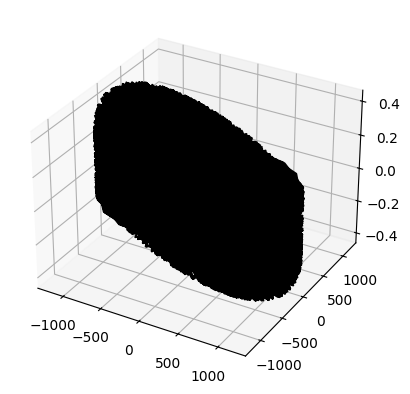

# Dimorphos orbit completed!



In [3]:
# Dimorphos orbit
if (1):
    print("# Plotting Dimorphos orbit ...",flush=True)
    didy_pos  = particle[0]['pos']
    dimor_pos = particle[1]['pos']
    n_p = 10
    np_pos    = particle[n_p]['pos']

    plt.figure().add_subplot(projection='3d')
    plt.plot(dimor_pos[:, 0] - didy_pos[:, 0],
             dimor_pos[:, 1] - didy_pos[:, 1],
             dimor_pos[:, 2] - didy_pos[:, 2], 
             label = 'Dimorphos orbit', linewidth=1.5, color='k')
    #plt.plot(np_pos[:, 0] - didy_pos[0:len(np_pos), 0],
    #         np_pos[:, 1] - didy_pos[0:len(np_pos), 1],
    #         np_pos[:, 2] - didy_pos[0:len(np_pos), 2],
    #         label = f'particle {n_p} orbit', linewidth=1.5)
    plt.savefig('dimor_orbit.png',dpi=300)
    plt.show()
    plt.close()
    print("# Dimorphos orbit completed!\n",flush=True)

# Plotting locations of particles at a time slice ...


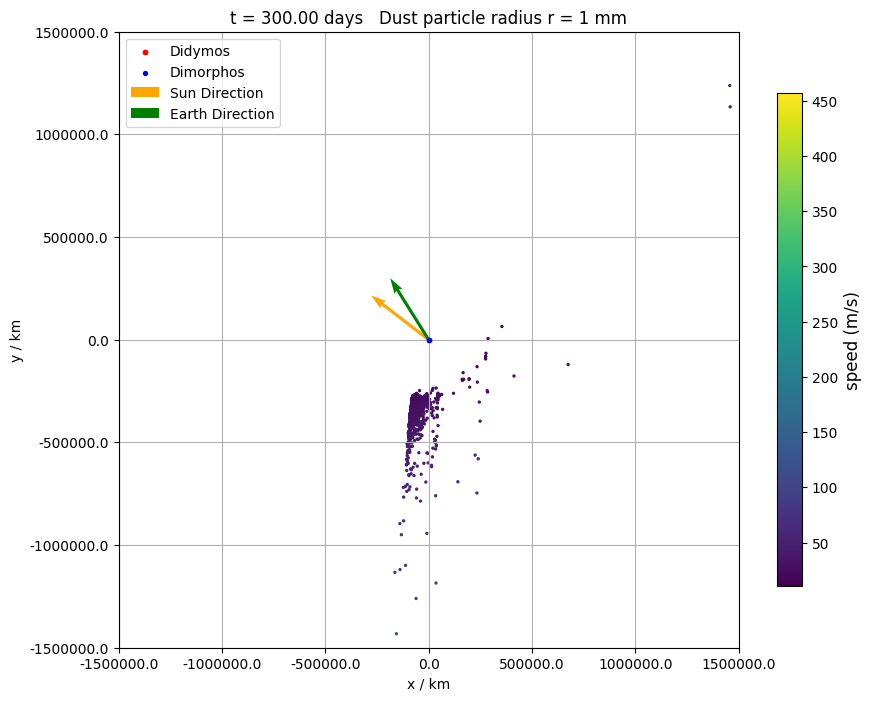

# Locations of particles completed!



In [54]:
# Scatter plot for certain time step
if (1):
    print("# Plotting locations of particles at a time slice ...",flush=True)
    t_idx = -1
    sec = time[t_idx]
    p_t = data_p[t_idx]

    plt.figure(figsize=(10,8))
    
    # plot locations of Didymos and Dimorphos
    plt.scatter(p_t[0, 1], p_t[0, 2], c='red', s=10, zorder=3, label='Didymos')
    plt.scatter(p_t[1, 1], p_t[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')
   
    # calculate speed of dust particles
    speed = (p_t[4:, 4]**2 + p_t[4:, 5]**2 + p_t[4:, 6]**2)**0.5
    
    # plot dust particles
    dust_sc = plt.scatter(p_t[4:, 1], p_t[4:, 2], c=speed, s=2, cmap='viridis')
    cb = plt.colorbar(dust_sc, shrink=0.8, aspect=20)
    cb.set_label(f'speed (m/s)', fontsize=12)

    # add the Sun direction relative to Didymos System Barycenter
    sun_x = p_t[2, 1]
    sun_y = p_t[2, 2]
    sun_distance = (sun_x**2 + sun_y**2) ** 0.5
    arrow_x = sun_x / sun_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
    arrow_y = sun_y / sun_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
    plt.quiver(0., 0., arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

    # add the Earth direction relative to Didymos System Barycenter
    earth_x = p_t[3, 1]
    earth_y = p_t[3, 2]
    earth_distance = (earth_x**2 + earth_y**2) ** 0.5
    arrow_x = earth_x / earth_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
    arrow_y = earth_y / earth_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
    plt.quiver(0., 0., arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='green', label='Earth Direction')    

    # Customize axis ticks to display in kilometers
    ax = plt.gca()
    ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
    ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))

    # set x and y limit
    axis_lim = 1500000e3  # m
    plt.xlim(-axis_lim, axis_lim)
    plt.ylim(-axis_lim, axis_lim)
    
    plt.xlabel('x / km')
    plt.ylabel('y / km')
    plt.title(f't = {sec/86400:.2f} days   Dust particle radius r = 1 mm')
    #plt.axis('equal')
    plt.grid()
    plt.legend()
    plt.savefig(f't{t_idx}_scatter.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
    plt.show()
    plt.close()
    print("# Locations of particles completed!\n",flush=True)

# plot the particles from the perspective of Hubble ...
# date: 2023-07-23 23:17:04.183000


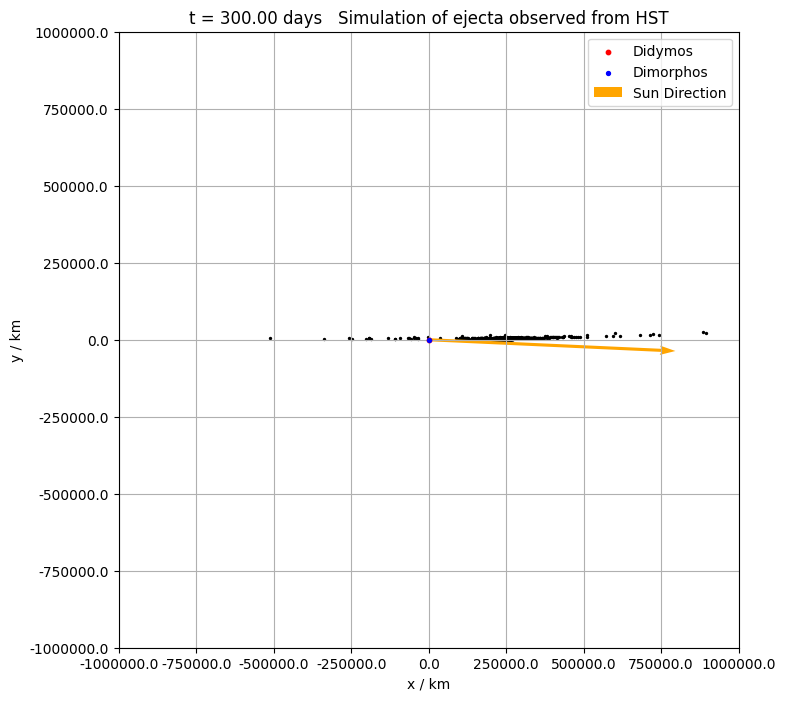

# HST simulation completed!



In [51]:
# view dust particles from HST
print("# plot the particles from the perspective of Hubble ...",flush=True)
t_idx = -1  # specify the time slice to plot
sec = time[t_idx]

start_time = datetime.strptime("2022-09-26 23:17:04.1830", "%Y-%m-%d %H:%M:%S.%f") # 160s after impact
new_time = start_time + timedelta(seconds=sec)
print(f"# date: {new_time}")

# the rotation matrix converting vector from reference frame 'Sun body center' 
# to the inertial reference frame of 'Didymos System Barycenter'
rotate_matrix = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])

p_t = data_p[t_idx]
# position and velocity vector of Sun
r_sun = p_t[2, 1:4]
v_sun = p_t[2, 4:7]

# position vector of Earth (as a proxy of HST)
r_earth = p_t[3, 1:4]

# get position vector of Hubble in reference frame 'Sun body center'
#r_hubble_Sun = np.array([7.721404094618157E10, -1.309126317614033E11, 5.065374641641974E6])  # 25920000
# convert to position vector of Hubble in 'Didymos System Barycenter'
#r_hubble = r_sun + np.dot(rotate_matrix, r_hubble_Sun.T)

# calculate the two basis vectors of the projection plane
l1 = np.cross(r_earth, v_sun)
l2 = np.cross(l1, r_earth)
l1 = l1 / np.linalg.norm(l1)
l2 = l2 / np.linalg.norm(l2)

# create an array to record coordinates of particles projected onto the plane
p_projected = np.zeros((len(p_t),3), dtype=float)
p_projected[:, 0] = p_t[:, 0]   # copy the column of particle ID

for i in range(len(p_t)):
    p_projected[i,1] = np.dot(l2, p_t[i, 1:4])
    p_projected[i,2] = np.dot(l1, p_t[i, 1:4])

plt.figure(figsize=(8,8))

# plot Didymos and Dimorphos
plt.scatter(p_projected[0, 1], p_projected[0, 2], c='red', s=10, zorder=3, label='Didymos')
plt.scatter(p_projected[1, 1], p_projected[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')
# plot dust particles
dust_sc = plt.scatter(p_projected[3:, 1], p_projected[3:, 2], c='k', s=2)

# add the Sun direction relative to Didymos System Barycenter
sun_x = p_projected[2, 1]
sun_y = p_projected[2, 2]
sun_scale = (sun_x**2 + sun_y**2) ** 0.5
arrow_x = sun_x / sun_scale * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
arrow_y = sun_y / sun_scale * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
plt.quiver(0., 0., arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

# Customize axis ticks to display in kilometers
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))

#plt.axis('equal')
axis_lim = 1000000e3  # m
plt.xlim(-axis_lim, axis_lim)
plt.ylim(-axis_lim, axis_lim)
plt.xlabel('x / km')
plt.ylabel('y / km')
plt.title(f't = {sec/86400:.2f} days   Simulation of ejecta observed from HST')

plt.grid()
plt.legend()
plt.savefig(f'simHST_t{sec:.1f}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
plt.show()
plt.close()
print("# HST simulation completed!\n",flush=True)

In [ ]:
# a & e analysis

# specify timeslices to be analyzed
orbit_files = ['a_e_t0.csv','a_e_t12961547.csv','a_e_t25920000.csv']

for ofile in orbit_files:
    # processing
    t = ofile.split('t')[1].replace('.csv','')
    ae_array = np.genfromtxt(ofile,delimiter=',',skip_header=1)
    num_rows = np.shape(ae_array)[0]
    # add a fate column to the array of a_e data
    fate_column = np.zeros(num_rows)
    for i in range(num_rows):
        p_id = int(ae_array[i,0])
        p_fate = particle[p_id-1]['id_collide']
        fate_column[i] = p_fate
    ae_array = np.column_stack((ae_array,fate_column))
    
    # select rows of the three main bodies and dust particles
    p0 = ae_array[0]    # the row  of Didymos        in ae_array
    p1 = ae_array[1]    # the row  of Dimorphos      in ae_array
    p2 = ae_array[2]    # the row  of Sun            in ae_array
    p_ae = ae_array[3:] # the rows of dust particles in ae_array

    # Scatter plot with eccentricity shown in color 
    if (1):
        print("# Plotting particle locations with eccentricity ...",flush=True)
        
        # select particles with limited eccentricity and spatial range
        data1 = p_ae[p_ae[:,2]<=10.,:] # select particles with eccentricity <= 5. Don't plot others
        data2 = data1[(data1[:, 5] >= -10) & (data1[:, 5] <= 10), :] # select particles located within certain z range. Don't plot others
        
        plt.figure()
        # plot Dimorphos (x,y)
        #plt.scatter(p0[3], p0[4], c='red', s=10, zorder=3)
        plt.scatter(p1[3], p1[4], c='red', s=8, zorder=3)
        # plot dust particles (x,y), color as eccentricity
        dust_sc = plt.scatter(data1[3:, 3], data1[3:, 4], c=data1[3:, 2], s=2, cmap='gist_rainbow')
        cb = plt.colorbar(dust_sc)
        cb.set_label(f'Eccentricity', fontsize=12)
        
        plt.xlabel('x / m')
        plt.ylabel('y / m')
        plt.axis('equal')
        plt.title(f't = {t} s')
        plt.grid()
        plt.savefig(f'location_e_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Plotting particle locations with eccentricity completed!\n",flush=True)
    
    # Dust fate distribution in a and e space
    if (1):
        print("# Plotting dust fate distribution in a and e space ...",flush=True)
        plt.figure(figsize=(6,4))
        if p_ae[p_ae[:,-1] == 0].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 0,2], p_ae[p_ae[:,-1] == 0,1], s=5, label='Remaining')
        if p_ae[p_ae[:,-1] == 1].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 1,2], p_ae[p_ae[:,-1] == 1,1], s=5, label='Didy_col')
        if p_ae[p_ae[:,-1] == 2].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 2,2], p_ae[p_ae[:,-1] == 2,1], s=5, label='Dimor_col')
        if p_ae[p_ae[:,-1] == 3].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 3,2], p_ae[p_ae[:,-1] == 3,1], s=5, label='Escaped')
        #plt.title('Dust particle radius r = 1 mm')
        plt.xlabel('Eccentricity',size=12)
        plt.ylabel('Semimajor axis [m]',size=12)
        plt.legend(fontsize=10)
        plt.savefig(f'dustfate_ae_{t}s.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Dust fate distribution in a and e space completed!\n",flush=True)

    # Histogram for semi-major axis
    if (1):
        print("# Plotting histogram for semimajor axis ...",flush=True)
        bins = np.linspace(-100,11000,112)  # set bins for semimajor axis
        yscale_type = 'log'

        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,1], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Semimajor axis [m]')
        plt.ylabel('Number')
        plt.savefig(f'semimajor_axis_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))
        
        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,1], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,1], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,1], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,1], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Semimajor axis [m]' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'semimajor_axis_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for semimajor axis completed!\n",flush=True)

    # Histogram for eccentricity
    if (1):
        print("# Plotting histogram for eccentricity ...",flush=True)
        bins = np.linspace(-1,20,150)  # set bins for eccentricity
        yscale_type = 'log'
        
        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,2], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Eccentricity')
        plt.ylabel('Number')
        plt.savefig(f'eccentricity_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))

        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,2], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,2], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,2], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,2], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Eccentricity' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'eccentricity_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for eccentricity completed!\n",flush=True)